In [24]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [25]:
angry_train = np.load('../../feature_extraction/geometric_features/data_train/angry_features.npy')
disgust_train = np.load('../../feature_extraction/geometric_features/data_train/disgust_features.npy')
fear_train = np.load('../../feature_extraction/geometric_features/data_train/fear_features.npy') 
happy_train = np.load('../../feature_extraction/geometric_features/data_train/happy_features.npy')
neutral_train = np.load('../../feature_extraction/geometric_features/data_train/neutral_features.npy')
sad_train = np.load('../../feature_extraction/geometric_features/data_train/sad_features.npy')
suprise_train = np.load('../../feature_extraction/geometric_features/data_train/surprise_features.npy')

In [26]:
angry_test = np.load('../../feature_extraction/geometric_features/data_test/angry_features.npy')
disgust_test = np.load('../../feature_extraction/geometric_features/data_test/disgust_features.npy')
fear_test = np.load('../../feature_extraction/geometric_features/data_test/fear_features.npy') 
happy_test = np.load('../../feature_extraction/geometric_features/data_test/happy_features.npy')
neutral_test = np.load('../../feature_extraction/geometric_features/data_test/neutral_features.npy')
sad_test = np.load('../../feature_extraction/geometric_features/data_test/sad_features.npy')
suprise_test = np.load('../../feature_extraction/geometric_features/data_test/surprise_features.npy')

In [27]:
train_data = {
    'angry': angry_train,
    'disgust': disgust_train,
    'fear': fear_train,
    'happy': happy_train,
    'neutral': neutral_train,
    'sad': sad_train,
    'suprise': suprise_train
}

In [28]:
test_data = {
    'angry': angry_test,
    'disgust': disgust_test,
    'fear': fear_test,
    'happy': happy_test,
    'neutral': neutral_test,
    'sad': sad_test,
    'suprise': suprise_test
}

In [29]:
train_X_list = []
train_y_list = []

for emotion, data in train_data.items():
    train_X_list.append(data.reshape(data.shape[0], -1))
    train_y_list.append(np.full((data.shape[0],), emotion))


X_train = np.concatenate(train_X_list, axis=0)
y_train = np.concatenate(train_y_list, axis=0)

In [30]:
test_X_list = []
test_y_list = []

for emotion, data in test_data.items():
    test_X_list.append(data.reshape(data.shape[0], -1))
    test_y_list.append(np.full((data.shape[0],), emotion))

X_test = np.concatenate(test_X_list, axis=0)
y_test = np.concatenate(test_y_list, axis=0)

In [31]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

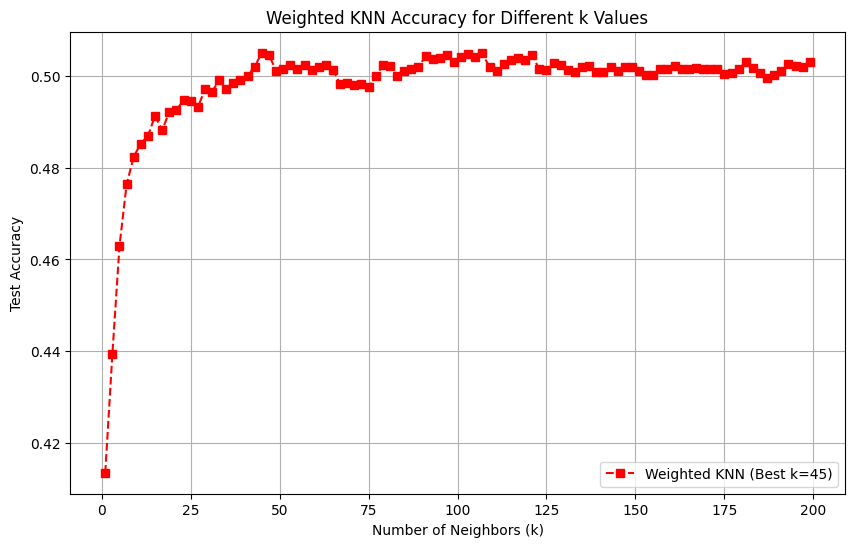

NameError: name 'best_k_uniform' is not defined

In [ ]:
def evaluate_knn(X_train_scaled, y_train, X_test_scaled, y_test, k_max=201):
    k_values = range(1, k_max, 2)
    accuracy_uniform = []
    accuracy_weighted = []

    for k in k_values:

        knn_weighted = KNeighborsClassifier(n_neighbors=k, weights="distance")
        knn_weighted.fit(X_train_scaled, y_train)
        acc_weighted = knn_weighted.score(X_test_scaled, y_test)
        accuracy_weighted.append(acc_weighted)

    best_k_weighted = k_values[np.argmax(accuracy_weighted)]
    best_acc_weighted = max(accuracy_weighted)
    plt.figure(figsize=(10, 6))
    plt.plot(k_values, accuracy_weighted, marker='s', linestyle='--', label=f"Weighted KNN (Best k={best_k_weighted})", color='red')
    plt.xlabel("Number of Neighbors (k)")
    plt.ylabel("Test Accuracy")
    plt.title("Weighted KNN Accuracy for Different k Values")
    plt.legend()
    plt.grid(True)
    plt.show()

    return (best_k_weighted, best_acc_weighted)

(weighted_k, weighted_result) = evaluate_knn(X_train_scaled, y_train, X_test_scaled, y_test)

In [ ]:
print(f"Best Weighted KNN: k={weighted_k}, Accuracy={weighted_result:.4f}")

In [ ]:
knn = KNeighborsClassifier(n_neighbors=45, weights="distance")
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=45, weights='distance')

In [ ]:
accuracy = knn.score(X_test_scaled, y_test)
print("\nTest Accuracy:", accuracy)


Test Accuracy: 0.5049758745476478
